In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
file_path = "General Sales Data Report v1.xlsx"
df = pd.read_excel(file_path, header = 3)
df.head()

,Category,Invoice,Sales Order,Customer,TR,Branch Sales Order,Date,Stock Code,LOB,Stock Description,WH,Order Qty,Price,Ex VAT,Total ex VAT,Unnamed: 15,Rep,Sales Rep,Customer Class
0,Accessories-Audio Device,TR021347,TR0000000032456,TR00001,TR,TR0000000032456,2025-03-19 16:44:17.203,VK-20034-BK-G-NEW,TM_Acc,Mou-Volkano Vector Vivid series wireless BLK New,TRA,1,139.00,120.87,120.87,NaN,C07561,Mkhasibe Tebogo,EN
1,Hardware-CPU Mobile,TR022908,TR0000000034118,RB00924,TR,TR0000000034118,2025-06-12 16:19:08.747,MOD-14-C7M-257ZA/512S-A,TM_Windows,"NB-MSI Mod R7 3 16GB 512GB PCIE W11H 14"" Blk A",TRA,1,10798.99,9390.43,9390.43,NaN,C05874,Namakwa Michael,EN
2,Accessories-CPU Add-on,TR022009,TR0000000033157,TR00001,TR,TR0000000033157,2025-04-22 11:07:51.817,910-004640-NEW,TM_Acc,Mou-Logitech M171 wireless mouse Blue New,TRA,1,289.00,251.30,251.30,NaN,C07561,Mkhasibe Tebogo,EN
3,Accessories-Input Device,TR022563,TR0000000033744,RB00785,TR,TR0000000033744,2025-05-22 17:04:27.503,LD4AS016G-B3200GSST-NEW,TM_Acc,Mem-Lexar 16GB DDR4 3200MHz SODIMM NB New,TRA,1,999.01,868.70,868.70,NaN,C06144,Makathini Msizi,EN
4,Hardware-Cellular,TR024823,TR0000000036145,RB01704,TR,TR0000000036145,2025-10-09 17:36:29.137,SAMS23U/512/5G/DS/LAV-C,TM_Samsung_Phone,Phone-Sam Gal S23 Ultra 512GB 5G DS Lavender C,TRA,1,14199.00,12346.96,12346.96,NaN,C07561,Mkhasibe Tebogo,EN


In [ ]:
# Strip accidental spaces from column names (e.g., ' Date' becomes 'Date')
df.columns = df.columns.str.strip()

# Drop any columns that are completely empty 
df = df.dropna(how='all', axis=1)

# Check the data types and count missing values
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 28394 entries, 0 to 28393
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Category            28394 non-null  str           
 1   Invoice             28394 non-null  str           
 2   Sales Order         28394 non-null  str           
 3   Customer            28394 non-null  str           
 4   TR                  28394 non-null  str           
 5   Branch Sales Order  12934 non-null  str           
 6   Date                28394 non-null  datetime64[us]
 7   Stock Code          28394 non-null  str           
 8   LOB                 27924 non-null  str           
 9   Stock Description   28394 non-null  str           
 10  WH                  28394 non-null  str           
 11  Order Qty           28394 non-null  int64         
 12  Price               28394 non-null  float64       
 13  Ex VAT              28392 non-null  float64       
 14  T

In [5]:
# Group the data by Stock Code and Description, summing Revenue and Quantity
product_perf = df.groupby(['Stock Code', 'Stock Description']).agg(
    Total_Revenue=('Total ex VAT', 'sum'),
    Total_Qty=('Order Qty', 'sum')
).reset_index()

# Sort to find the Top 5
top_5 = product_perf.sort_values(by='Total_Revenue', ascending=False).head(5)
print("--- TOP 5 PERFORMING PRODUCTS ---")
print(top_5[['Stock Code', 'Stock Description', 'Total_Revenue', 'Total_Qty']])

# Filter out negative values (returns/fees) and system test entries to find true bottom sellers
actual_products = product_perf[(product_perf['Total_Revenue'] > 50) & 
                               (~product_perf['Stock Description'].str.contains('Other Income|test', case=False, na=False))]

bottom_5 = actual_products.sort_values(by='Total_Revenue', ascending=True).head(5)
print("\n--- LEAST PERFORMING PRODUCTS ---")
print(bottom_5[['Stock Code', 'Stock Description', 'Total_Revenue', 'Total_Qty']])

--- TOP 5 PERFORMING PRODUCTS ---
                     Stock Code  \
344     5490/I5-8350U/16/512S-B   
3991     X1504ZA-I38512BL0W-NEW   
2291                  MP1J2HC-C   
3849              V1165C4I120-B   
2273  MODERN-14-F13MG-039ZA-NEW   

                                      Stock Description  Total_Revenue  \
344      NB-Dell Lat i5 8 16GB 512GB SSD W11P 14" Blk B      623794.21   
3991  NB-Asus Vivo i3 12 8GB 512GBPCIE W11H 15" Blue...      550005.90   
2291      iPad-5th Gen 9.7" 32GB Wifi+Cell Space Grey C      483516.05   
3849    NB-Proline V11 N4020 4GB 120GBSSD W11H 11"Blk B      433110.40   
2273   NB-MSImod 14 i3 13 8GB 256GB PCIE W11H 14" Gry N      428736.18   

      Total_Qty  
344         120  
3991         93  
2291        500  
3849        321  
2273         94  

--- LEAST PERFORMING PRODUCTS ---
           Stock Code                                  Stock Description  \
35           135735-N   CABLE-HAMA USB TYPE-C ADAPTER  USB 3.1 0.75M NEW   
1102  CABAPL30P

C:\Users\tamee\AppData\Local\Temp\ipykernel_27076\629305832.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_customers, x='Customer', y='Total ex VAT', palette='viridis')


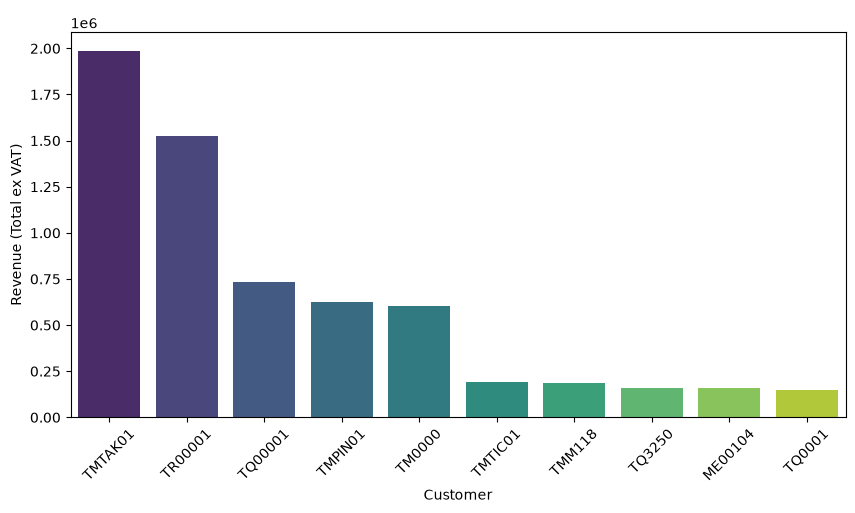

Top Customer: TMTAK01 | Revenue: R 1,987,511.57


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total revenue per customer
customer_value = df.groupby('Customer')['Total ex VAT'].sum().sort_values(ascending=False).reset_index()

# Extract the top 10
top_10_customers = customer_value.head(10)

# Plotting
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_customers, x='Customer', y='Total ex VAT', palette='viridis')
plt.title('Top 10 Customers by Revenue', fontsize=14, color='white')
plt.xticks(rotation=45)
plt.ylabel('Revenue (Total ex VAT)')
plt.show()

print("Top Customer:", top_10_customers.iloc[0]['Customer'], 
      "| Revenue: R", f"{top_10_customers.iloc[0]['Total ex VAT']:,.2f}")

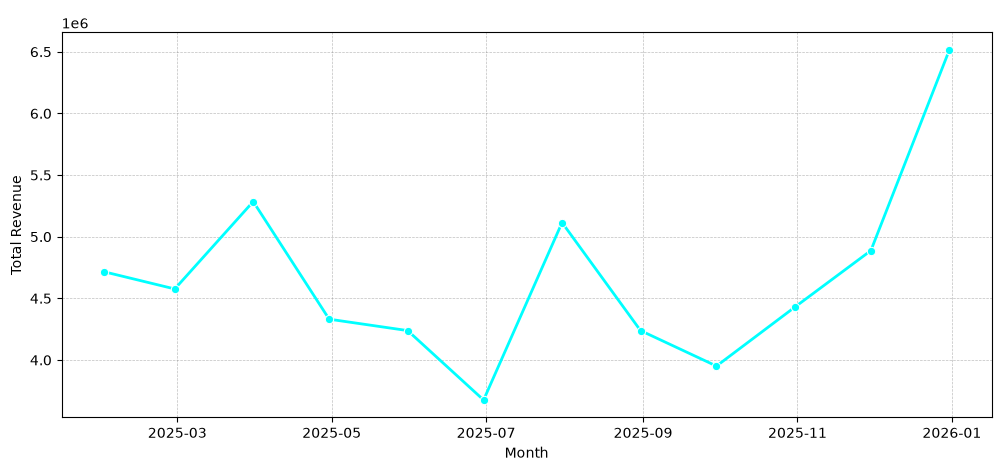

In [7]:
# Ensure Date is a datetime object and set it as the index
df['Date'] = pd.to_datetime(df['Date'])
time_df = df.set_index('Date')

# Resample to group total revenue by Month ('ME' = Month End)
monthly_sales = time_df.resample('ME')['Total ex VAT'].sum().reset_index()

# Plotting
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='Date', y='Total ex VAT', color='cyan', marker='o', linewidth=2)
plt.title('Monthly Sales Revenue (2025)', fontsize=14, color='white')
plt.ylabel('Total Revenue')
plt.xlabel('Month')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.show()

In [4]:
# Group by Sales Rep and sum the Total ex VAT, sorting from highest to lowest
top_reps = df.groupby('Sales Rep')['Total ex VAT'].sum().sort_values(ascending=False)

# Format the output as currency
top_reps_formatted = top_reps.apply(lambda x: f"R {x:,.2f}")
print(top_reps_formatted.head(10))

Sales Rep
Ecommerce SalesRep         R 14,954,295.17
Head Office                 R 6,867,254.79
Namakwa Michael             R 4,743,359.49
Mkhasibe Tebogo             R 4,240,157.12
Mothshwene Thapelo Theo     R 3,769,930.28
Unmanaged                   R 3,592,262.94
Sebelebele Tebogo           R 3,202,047.60
Maruno Paballo              R 3,189,487.37
Magane Lesego               R 3,167,621.67
Maratela Mbuyiselo          R 3,010,440.70
Name: Total ex VAT, dtype: str


C:\Users\tamee\AppData\Local\Temp\ipykernel_27076\462394390.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lob_sales, y='LOB', x='Total ex VAT', ax=axes[0], palette='magma')
C:\Users\tamee\AppData\Local\Temp\ipykernel_27076\462394390.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wh_sales, x='WH', y='Total ex VAT', ax=axes[1], palette='flare')


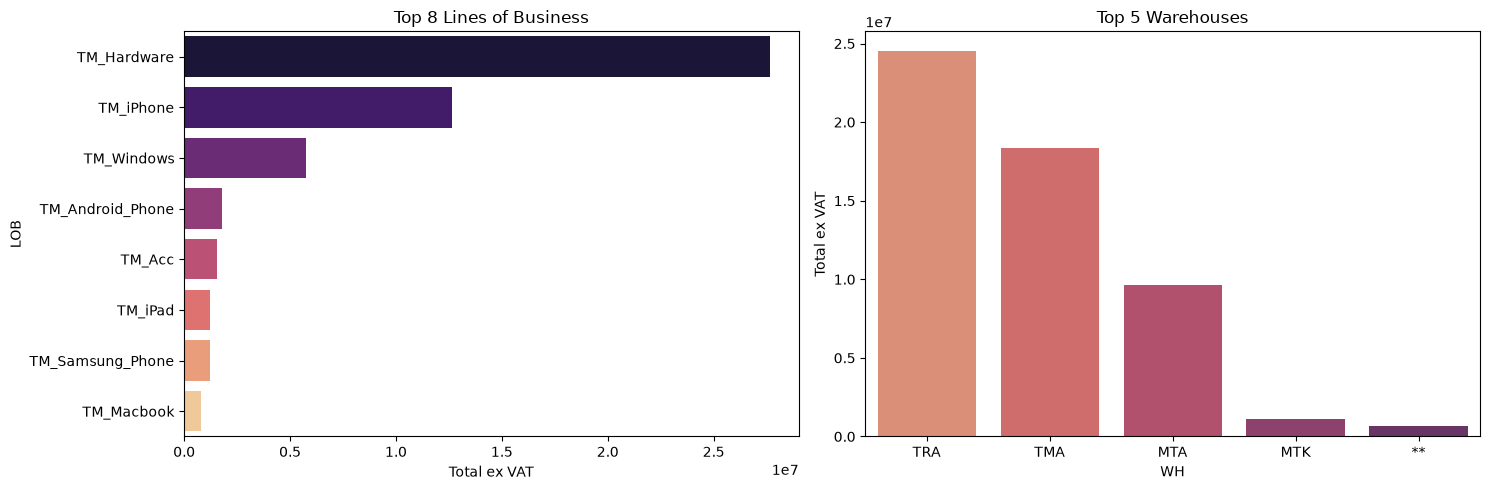

In [9]:
# Calculate revenue by Line of Business (LOB)
lob_sales = df.groupby('LOB')['Total ex VAT'].sum().sort_values(ascending=False).reset_index().head(8)

# Calculate revenue by Warehouse (WH)
wh_sales = df.groupby('WH')['Total ex VAT'].sum().sort_values(ascending=False).reset_index().head(5)

# Setup a 1x2 subplot for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot LOB
sns.barplot(data=lob_sales, y='LOB', x='Total ex VAT', ax=axes[0], palette='magma')
axes[0].set_title('Top 8 Lines of Business')

# Plot Warehouse
sns.barplot(data=wh_sales, x='WH', y='Total ex VAT', ax=axes[1], palette='flare')
axes[1].set_title('Top 5 Warehouses')

plt.tight_layout()
plt.show()

In [10]:
# Filter the dataset for transactions where the Order Quantity is less than 0
returns_df = df[df['Order Qty'] < 0]

# Group by the product description to see what is being returned or credited most often
top_returns = returns_df.groupby('Stock Description').agg(
    Returned_Qty=('Order Qty', 'sum'),
    Lost_Revenue=('Total ex VAT', 'sum')
).sort_values(by='Lost_Revenue', ascending=True)

# Format the Lost Revenue as currency for readability
top_returns['Lost_Revenue'] = top_returns['Lost_Revenue'].apply(lambda x: f"R {x:,.2f}")

print("--- TOP REVENUE LEAKS (RETURNS & CREDITS) ---")
print(top_returns.head(10))

--- TOP REVENUE LEAKS (RETURNS & CREDITS) ---
                                                    Returned_Qty  \
Stock Description                                                  
NB-MSImod 14 i5 13 8GB 512GB PCIE W11H 14" Gry N              -7   
Other Income                                                 -21   
NB-Dell Lat i5 8 16GB 512GB SSD W11P 14" Blk B               -13   
Phone-Sam Gal S22 256GB 5G DS Black B                        -36   
Phone-Sam Gal S22 256GB 5G DS Green B                        -27   
e-Commerce commission                                       -235   
Phone-Samsung S25 Ultra 256GB 5G DS Black A+                  -3   
NB-Dell i7 11 16GB 512SSD W10H 2-in-1 Nvd 14"Gry A            -5   
iPad- 5th gen 32GB Wifi  + Cell Pace Grey B                  -37   
Macbook-Air M2 8GB 256GBSSD 15'' 2023 SG New                  -3   

                                                         Lost_Revenue  
Stock Description                                                

In [12]:
import pandas as pd
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.chart import LineChart, Reference

# FIX THE 980 MILLION ERROR
correct_price = 9800.00
error_indices = [14258, 23654]
df.loc[error_indices, 'Price'] = correct_price
df.loc[error_indices, 'Total ex VAT'] = (df.loc[error_indices, 'Price'] / 1.15) * df.loc[error_indices, 'Order Qty']
print("Ledger errors fixed.")

# GENERATE SUMMARY DATAFRAMES
# Monthly Sales
monthly_sales = df.set_index('Date').resample('ME')['Total ex VAT'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Date'].dt.strftime('%b %Y')

# Top Customers
top_customers = df.groupby('Customer')['Total ex VAT'].sum().sort_values(ascending=False).head(20).reset_index()

# Top Returns
returns_df = df[df['Order Qty'] < 0]
top_returns = returns_df.groupby('Stock Description').agg(
    Returned_Qty=('Order Qty', 'sum'),
    Lost_Revenue=('Total ex VAT', 'sum')
).sort_values(by='Lost_Revenue', ascending=True).head(20).reset_index()

# Top Lines of Business
lob_sales = df.groupby('LOB')['Total ex VAT'].sum().sort_values(ascending=False).head(15).reset_index()

# EXPORT TO EXCEL WITH STYLING
file_name = "Cleaned_Sales_Summary.xlsx"
with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    monthly_sales.to_excel(writer, sheet_name='Monthly Sales', index=False)
    lob_sales.to_excel(writer, sheet_name='Top LOBs', index=False)
    top_customers.to_excel(writer, sheet_name='Top Customers', index=False)
    top_returns.to_excel(writer, sheet_name='Top Returns', index=False)
    
    workbook = writer.book
    
    # Define Dark Theme Header Styling
    header_fill = PatternFill(start_color="2A2A2A", end_color="2A2A2A", fill_type="solid")
    header_font = Font(color="FFFFFF", bold=True)
    border = Border(left=Side(style='thin', color='DDDDDD'),
                    right=Side(style='thin', color='DDDDDD'),
                    top=Side(style='thin', color='DDDDDD'),
                    bottom=Side(style='thin', color='DDDDDD'))
    
    for sheet_name in workbook.sheetnames:
        ws = workbook[sheet_name]
        
        # Apply Header Styles
        for cell in ws[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(horizontal='center')
            cell.border = border
            
        # Apply Borders to all data cells and adjust column widths
        for col in ws.columns:
            max_length = 0
            col_letter = col[0].column_letter
            for cell in col:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                    cell.border = border
                except:
                    pass
            ws.column_dimensions[col_letter].width = (max_length + 3)
            
        # Format Currency Columns
        currency_format = '"R" #,##0.00'
        if sheet_name == 'Monthly Sales':
            for cell in ws['B'][1:]: cell.number_format = currency_format
        elif sheet_name == 'Top LOBs':
            for cell in ws['B'][1:]: cell.number_format = currency_format
        elif sheet_name == 'Top Customers':
            for cell in ws['B'][1:]: cell.number_format = currency_format
        elif sheet_name == 'Top Returns':
            for cell in ws['C'][1:]: cell.number_format = currency_format
            
        ws.freeze_panes = 'A2'

    # Add Line Chart to Monthly Sales tab
    ws_monthly = workbook['Monthly Sales']
    line_chart = LineChart()
    line_chart.title = "Monthly Revenue Trend"
    line_chart.style = 13
    line_chart.y_axis.title = "Revenue (ZAR)"
    line_chart.x_axis.title = "Month"
    line_chart.width = 16
    line_chart.height = 8
    
    data = Reference(ws_monthly, min_col=2, min_row=1, max_row=len(monthly_sales)+1)
    cats = Reference(ws_monthly, min_col=1, min_row=2, max_row=len(monthly_sales)+1)
    line_chart.add_data(data, titles_from_data=True)
    line_chart.set_categories(cats)
    ws_monthly.add_chart(line_chart, "D2")


Ledger errors fixed.


PermissionError: [Errno 13] Permission denied: 'Cleaned_Sales_Summary.xlsx'